In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = '/content/drive/MyDrive/oruntu_tanima_proje'
DATASET_DIR = os.path.join(PROJECT, 'dataset')
PREP_DIR = os.path.join(PROJECT, 'veri_hazirlik')
LOCAL_RAW = '/content/raw'
os.makedirs(LOCAL_RAW, exist_ok=True)
print('Drive mounted. Folders:', os.listdir(PROJECT))

Mounted at /content/drive
Drive mounted. Folders: ['dataset', 'makale', 'yontemler', 'veri_hazirlik']


In [3]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

Saving kaggle.json to kaggle.json


In [4]:
!kaggle datasets download -d abhranta/brain-tumor-detection-mri -p /content/raw --unzip

import os
for root, dirs, fnames in os.walk('/content/raw'):
    depth = root.replace('/content/raw', '').count(os.sep)
    print('  ' * depth, os.path.basename(root), f'({len(fnames)} files)')
    if depth >= 2:
        dirs[:] = []

Dataset URL: https://www.kaggle.com/datasets/abhranta/brain-tumor-detection-mri
License(s): unknown
100% 64.3M/64.3M [00:01<00:00, 41.1MB/s]

 raw (0 files)
   Brain_Tumor_Detection (0 files)
     pred (60 files)
     no (1500 files)
     yes (1500 files)


In [5]:
import shutil, glob, os

BASE = '/content/raw/Brain_Tumor_Detection'
src_yes  = os.path.join(BASE, 'yes')    # tumor
src_no   = os.path.join(BASE, 'no')     # healthy
src_pred = os.path.join(BASE, 'pred')   # unlabelled -> NOT used

print('yes :', len(glob.glob(src_yes + '/*')))
print('no  :', len(glob.glob(src_no + '/*')))
print('pred:', len(glob.glob(src_pred + '/*')), '(unlabelled -> will NOT be used)')

# Copy yes/no into Drive dataset/yes and dataset/no (once)
for cls, src in [('yes', src_yes), ('no', src_no)]:
    dst = os.path.join(DATASET_DIR, cls)
    os.makedirs(dst, exist_ok=True)
    for f in glob.glob(src + '/*'):
        shutil.copy(f, dst)
    print(cls, '->', len(os.listdir(dst)), 'files copied')

yes : 1500
no  : 1500
pred: 60 (unlabelled -> will NOT be used)
yes -> 1500 files copied
no -> 1500 files copied


In [6]:
import glob, json, os
from sklearn.model_selection import train_test_split

SEED = 42
yes_files = sorted(glob.glob(os.path.join(DATASET_DIR, 'yes', '*')))
no_files  = sorted(glob.glob(os.path.join(DATASET_DIR, 'no', '*')))

def split_70_10_20(files, seed=SEED):
    # first 80% train+val, 20% test; then 12.5% of the 80% -> 10% val
    trainval, test = train_test_split(files, test_size=0.20, random_state=seed)
    train, val = train_test_split(trainval, test_size=0.125, random_state=seed)
    return train, val, test

ytr, yvl, yte = split_70_10_20(yes_files)
ntr, nvl, nte = split_70_10_20(no_files)

# Store paths relative to the project root (portable)
def rel(paths):
    return [os.path.relpath(p, PROJECT) for p in paths]

split = {
    'seed': SEED,
    'label_map': {'yes': 1, 'no': 0},
    'train': {'yes': rel(ytr), 'no': rel(ntr)},
    'val':   {'yes': rel(yvl), 'no': rel(nvl)},
    'test':  {'yes': rel(yte), 'no': rel(nte)},
}
with open(os.path.join(PREP_DIR, 'split_index.json'), 'w') as f:
    json.dump(split, f, indent=2)

print('Saved: veri_hazirlik/split_index.json')
print(f'TRAIN  yes:{len(ytr)} no:{len(ntr)}')
print(f'VAL    yes:{len(yvl)} no:{len(nvl)}')
print(f'TEST   yes:{len(yte)} no:{len(nte)}')

Saved: veri_hazirlik/split_index.json
TRAIN  yes:1050 no:1050
VAL    yes:150 no:150
TEST   yes:300 no:300


No image appears in more than one set.


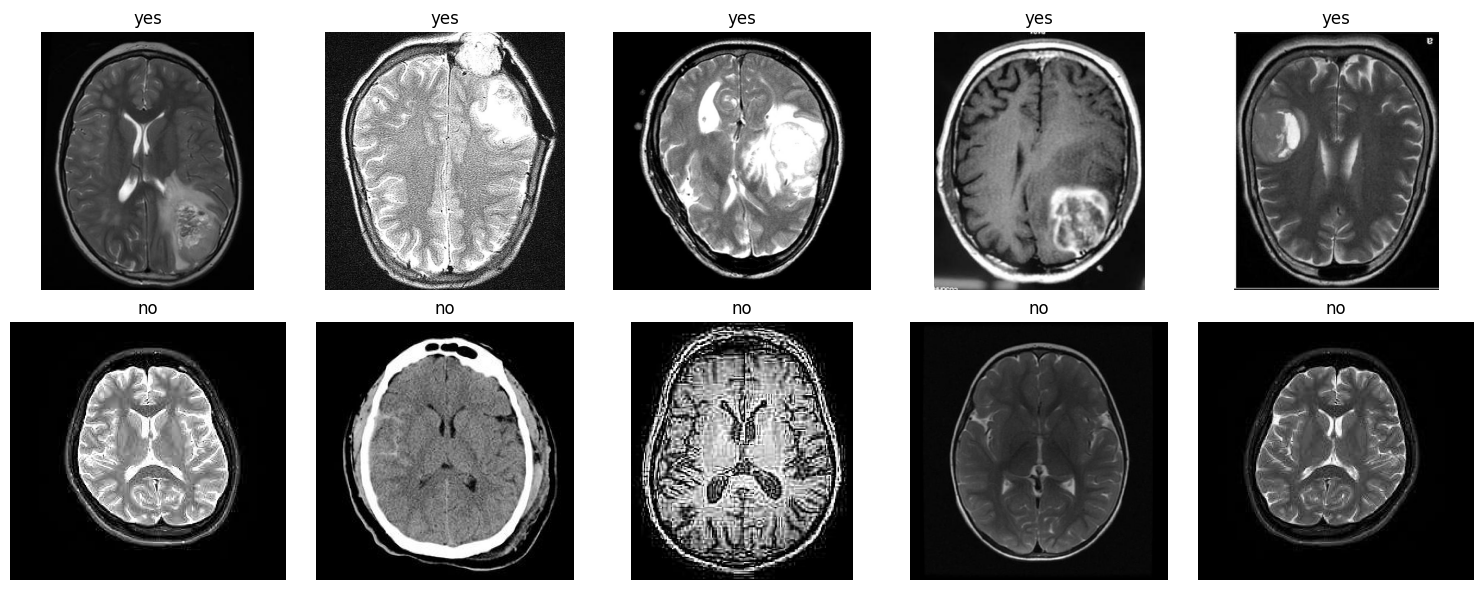

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Overlap check
sets = {s: set(split[s]['yes']) | set(split[s]['no']) for s in ['train', 'val', 'test']}
assert not (sets['train'] & sets['val']),  'train-val overlap!'
assert not (sets['train'] & sets['test']), 'train-test overlap!'
assert not (sets['val']   & sets['test']), 'val-test overlap!'
print('No image appears in more than one set.')

# Sample images
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for i, p in enumerate(ytr[:5]):
    ax[0, i].imshow(Image.open(os.path.join(PROJECT, p)))
    ax[0, i].axis('off'); ax[0, i].set_title('yes')
for i, p in enumerate(ntr[:5]):
    ax[1, i].imshow(Image.open(os.path.join(PROJECT, p)))
    ax[1, i].axis('off'); ax[1, i].set_title('no')
plt.tight_layout(); plt.show()